In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as scp
import PIL
import requests



In [80]:
data_path = 'omafra_farrow_to_finish_enterprise_budget_monthly_summaries.csv'
data = np.genfromtxt(data_path, dtype=str, delimiter=',')

In [81]:
variables = data[0]
print(variables)

['Year' 'Month' 'Estimated Market Hog Value' 'Dressed Weight (kg)'
 'Feed Costs' 'Other Variable Costs' 'Fixed Costs' 'Total Cost per Pig'
 'Net Return']


In [83]:
## get the quantitative data in this dataset
pig_data = data[1:].copy()

## Remove the dollar sign to make each number a float later
pig_data = np.char.replace(pig_data, '$', '')

## Replace month with a number corresponding to the month
months_list = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for i in np.arange(len(months_list)):
    pig_data = np.char.replace(pig_data, months_list[i], str(i))
    
## Replace missing data with np.nan
pig_data[pig_data== ''] = np.nan

## change to float
pig_data = pig_data.astype('float')

In [114]:
## I want to do a line plot showing what months is is most profitable to sell a pig on Ontario as well as
## a colourmesh showing how this month changes over the years.
## Here are 2 main goals 1) what month should I sell my pig? and 2) how does this month change over time

## Define x and y on colourmesh:
years = pig_data[:,0].reshape(25,12)
months = pig_data[:,1].reshape(25,12)

ROI = pig_data[:,-1].reshape(25,12)

## Define error bars as std for a given month over every year, and the plotted points as mean monthly pig profit for each month:
ROI_month = np.mean(ROI,axis=0)
ROI_month_err = np.std(ROI,axis=0)

Text(0.5, 1.0, 'Return on Investment for Pigs \n in Ontario for each month between \n Jan 2001 and Dec 2025')

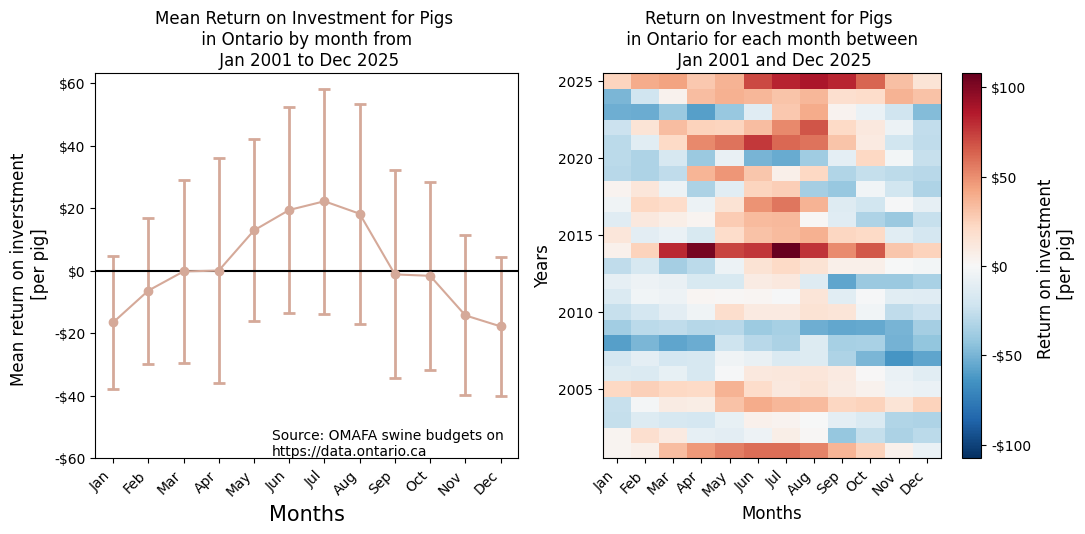

In [161]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(12,5),sharex=True)

#plot the mean and median profit per month over our range of years
ax[0].errorbar(np.arange(12),ROI_month,yerr = ROI_month_err,
               color='#D5A999', ## just having some fun with colours and line styles :)
               fmt='-o',
               ecolor='#D5A999',
               elinewidth=2,
               capsize=4,
               capthick=2)

## plot a line representing breaking even on selling pig at that month
ax[0].axhline(0,c='black')
ax[0].set_xticks(np.arange(12),labels = months_list,rotation=45,ha='right')
ax[0].set_xlabel('Months',size=15)

## Set units to dollars to easiely read
ax[0].set_yticks([60,40,20,0,-20,-40,-60],labels=['$60','$40','$20','$0','-$20','-$40','-$60'])
ax[0].set_ylabel('Mean return on inverstment \n [per pig]',size=12)

## I want to do a divergent colourmap for price, with one colour for profit and another for loss. So, I set
## The max and min on colorbar to be the same value, but positive and negative
## This way, it is easy to tell at a glance when we earn or loose money
cmax = np.max([np.abs(np.amax(ROI)),np.abs(np.amin(ROI))])

returns_grid = ax[1].pcolormesh(months,years,ROI,
                                vmax=cmax,vmin=-cmax, cmap='RdBu_r')

## make sure units are dollars
cbar = fig.colorbar(returns_grid, ax=ax[1],ticks = [-100,-50,0,50,100])
cbar.set_label('Return on investment \n [per pig]',fontsize=12)
cbar.ax.set_yticklabels(['-$100','-$50', '$0', '$50','$100'])

ax[1].set_xticks(np.arange(12),labels = months_list,rotation=45,ha='right')
ax[1].set_xlabel('Months',size=12)
ax[1].set_ylabel('Years',size=12)

## plot data source on the graph
ax[0].text(4.5,-59,'Source: OMAFA swine budgets on \nhttps://data.ontario.ca')

ax[0].set_title('Mean Return on Investment for Pigs \n in Ontario by month from \n Jan 2001 to Dec 2025',size=12)
ax[1].set_title('Return on Investment for Pigs \n in Ontario for each month between \n Jan 2001 and Dec 2025',size=12)